## Agent Based Modelling

In [2]:
pip install mesa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 12.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [mesa]5/6 [mesa]an]
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd


In [3]:
df = pd.read_csv("Mammary_data_response_1e8.csv")
df_T11 = df[df['Cell_Line'] == 'T11']
df_T11_ICI = df_T11[df_T11['Mouse_treatment']!='no_treatment']
df_T11_ICI

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
166,SRX5100724,0.001480,0.000810,0.000054,0.000361,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554847,T11,"Mammary cancer, NOS",GSE124821
169,SRX5100642,0.002127,0.001080,0.000074,0.000376,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554850,T11,"Mammary cancer, NOS",GSE124821
171,SRX5100638,0.005433,0.001761,0.000051,0.000530,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554852,T11,"Mammary cancer, NOS",GSE124821
172,SRX5100632,0.007120,0.002415,0.000192,0.000578,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554853,T11,"Mammary cancer, NOS",GSE124821
173,SRX5100675,0.005026,0.001591,0.000043,0.000476,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554854,T11,"Mammary cancer, NOS",GSE124821
175,SRX5100859,0.001926,0.000846,0.000024,0.000324,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554856,T11,"Mammary cancer, NOS",GSE124821
177,SRX5100857,0.004220,0.001382,0.000040,0.000431,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554858,T11,"Mammary cancer, NOS",GSE124821
180,SRX5100867,0.001831,0.000895,0.000002,0.000430,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554861,T11,"Mammary cancer, NOS",GSE124821
186,SRX5100790,0.003833,0.001607,0.000578,0.000508,antiPD1; antiCTLA4;,UV_day7,day7,R,GSM3554883,T11,"Mammary cancer, NOS",GSE124821
187,SRX5100789,0.005915,0.001772,0.000768,0.000565,antiPD1; antiCTLA4;,UV_day7,day7,R,GSM3554884,T11,"Mammary cancer, NOS",GSE124821


In [7]:
#treatment with mutagen
mutagen_Ds = []
mutagen_NKs = []
mutagen_T8s = []
mutagen_Tregs = []

scatter_mutagen_Ds = []
scatter_mutagen_NKs = []
scatter_mutagen_Tregs = []
scatter_mutagen_T8s = []
scatter_mutagen_times = []


quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

time_points = ["day3","day7","end"]


for day in time_points:
    day_df = df_T11_ICI[df_T11_ICI['Condition'].str.contains('_'+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    mutagen_NKs.append(averages["NK_quanTIseq"])
    mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    mutagen_total = sum(averages)
    print(mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_mutagen_Ds.append(i)
                scatter_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_mutagen_T8s.append(i)


Number of replicates 7
Dendritic_quanTIseq    0.004187
NK_quanTIseq           0.001479
T.CD8_quanTIseq        0.000074
Tregs_quanTIseq        0.000443
dtype: float64
<class 'pandas.Series'>
0.006182992517142857

Number of replicates 8
Dendritic_quanTIseq    0.004660
NK_quanTIseq           0.001701
T.CD8_quanTIseq        0.000798
Tregs_quanTIseq        0.000610
dtype: float64
<class 'pandas.Series'>
0.0077687861

Number of replicates 9
Dendritic_quanTIseq    0.002484
NK_quanTIseq           0.001149
T.CD8_quanTIseq        0.000036
Tregs_quanTIseq        0.000457
dtype: float64
<class 'pandas.Series'>
0.0041256423698666665


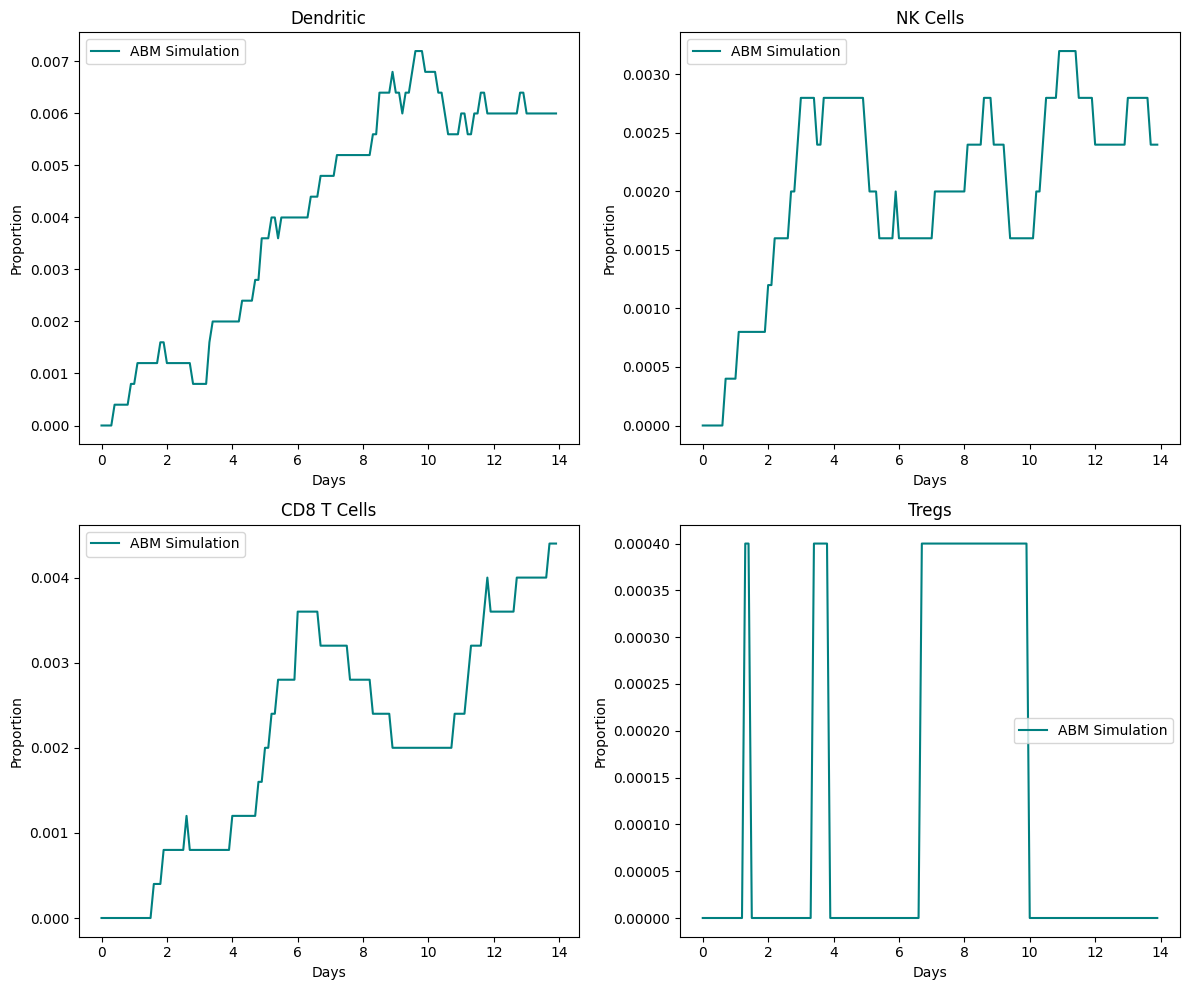

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters from your ODE ---
p = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004
}

# Simulation Settings
GRID_SIZE = 50
DAYS = 14
DT = 0.01  # Time step (smaller for stability)
STEPS = int(DAYS / DT)
TOTAL_SITES = GRID_SIZE**2

def run_abm():
    # Initialize Grids (0 = empty, 1 = cell present)
    # 0: Cancer, 1: Dendritic, 2: NK, 3: Tregs, 4: CD8
    grids = np.zeros((5, GRID_SIZE, GRID_SIZE))
    
    # Initial seeding based on your C_init (0.8)
    grids[0] = np.random.choice([0, 1], size=(GRID_SIZE, GRID_SIZE), p=[0.2, 0.8])
    
    history = {k: [] for k in ['C', 'D', 'N', 'Tr', 'T8']}
    time_axis = []

    for step in range(STEPS):
        t = step * DT
        
        # Calculate Global Proportions (used for some signaling terms)
        props = np.sum(grids, axis=(1, 2)) / TOTAL_SITES
        C, D, N, Tr, T8 = props

        # 1. Cancer Dynamics (Growth & Killing)
        # Prob of growth: lambda_C * (1 - C/C_M)
        growth_p = p['lambda_C'] * (1 - C/p['C_M']) * DT
        kill_p = (p['eta_8'] * T8 + p['eta_N'] * N + p['d_C']) * DT
        
        # Apply Cancer changes
        cancer_mask = grids[0] == 1
        # Random death/kill
        grids[0][cancer_mask & (np.random.rand(GRID_SIZE, GRID_SIZE) < kill_p)] = 0
        # Random birth in empty spots
        empty_mask = grids[0] == 0
        grids[0][empty_mask & (np.random.rand(GRID_SIZE, GRID_SIZE) < growth_p)] = 1

        # 2. Immune Recruitment (Stochastic events)
        # Dendritic Recruitment
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * DT
        grids[1][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < p['d_D']*DT)] = 0

        # NK recruitment and inhibition by Tr
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * DT
        grids[2][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_N)] = 1
        # NK death + Treg inhibition
        death_N = (p['d_N'] + p['gamma_N']*Tr) * DT
        grids[2][(grids[2] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < death_N)] = 0

        # Tregs
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * DT
        grids[3][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < p['d_Tr']*DT)] = 0

        # CD8 T Cells (Inhibited by Tregs)
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * DT
        grids[4][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < p['d_T8']*DT)] = 0

        if step % 10 == 0:
            for i, key in enumerate(history.keys()):
                history[key].append(props[i])
            time_axis.append(t)

    return time_axis, history

# Run Simulation
t_axis, results = run_abm()

# --- Plotting against your data ---
# Replace the placeholders below with your actual dataframe values
day3_vals = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day3']
day7_vals = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day7']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
mapping = {
    "Dendritic_quanTIseq": ('D', axes[0,0], 'Dendritic'),
    "NK_quanTIseq": ('N', axes[0,1], 'NK Cells'),
    "T.CD8_quanTIseq": ('T8', axes[1,0], 'CD8 T Cells'),
    "Tregs_quanTIseq": ('Tr', axes[1,1], 'Tregs')
}

for col, (key, ax, title) in mapping.items():
    ax.plot(t_axis, results[key], label='ABM Simulation', color='teal')
    
    # Plot Day 3 and Day 7 Data Points
    # Use your dataframe df_T11_ICI here
    ax.scatter([3]*len(day3_vals), day3_vals, color='red', label='Day 3 Data')
    ax.scatter([7]*len(day7_vals), day7_vals, color='blue', label='Day 7 Data')
    
    ax.set_title(title)
    ax.set_xlabel('Days')
    ax.set_ylabel('Proportion')
    ax.legend()

plt.tight_layout()
plt.show()

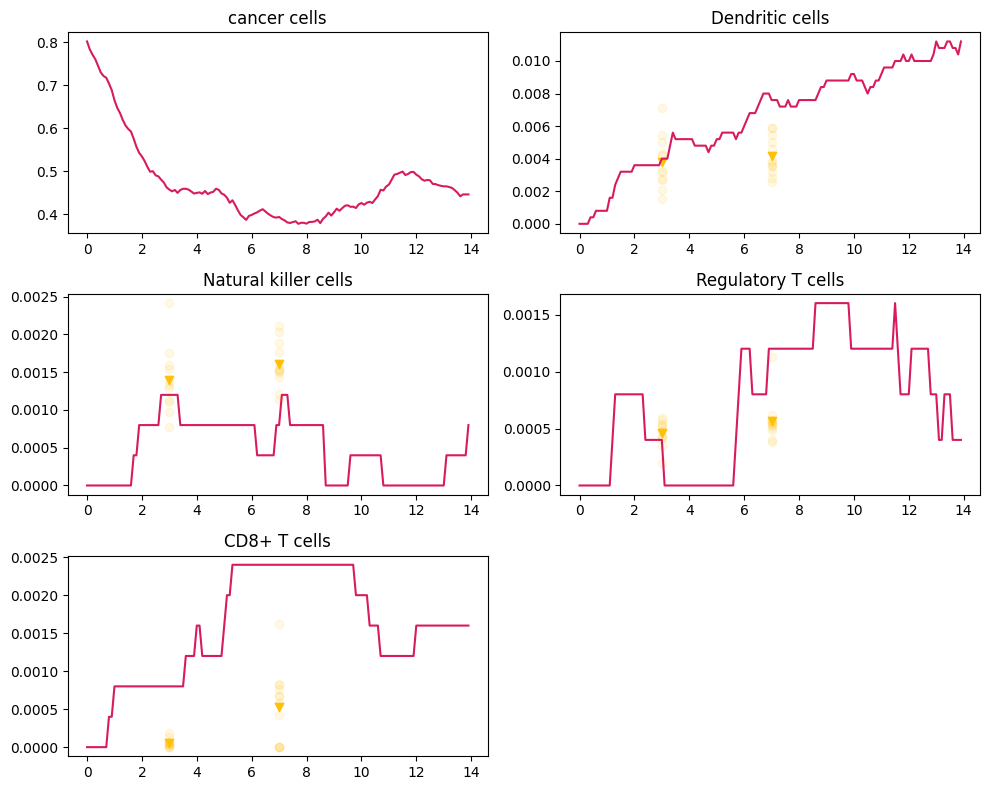

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Color Palette ---
c1 = (216/255, 27/255, 96/255)   # ABM Line
c3 = (255/255, 193/255, 7/255)   # Data Points

# --- Parameters & Initial Conditions ---
p = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8
}

GRID_SIZE = 50
DAYS = 14
DT = 0.01  
STEPS = int(DAYS / DT)
TOTAL_SITES = GRID_SIZE**2

def run_spatial_abm():
    # 0:C, 1:D, 2:N, 3:Tr, 4:T8
    grids = np.zeros((5, GRID_SIZE, GRID_SIZE))
    # Initial seeding for Cancer
    grids[0] = np.random.choice([0, 1], size=(GRID_SIZE, GRID_SIZE), p=[1-p['C_init'], p['C_init']])
    
    results = {k: [] for k in ['C', 'D', 'N', 'Tr', 'T8']}
    time_axis = []

    for step in range(STEPS):
        props = np.sum(grids, axis=(1, 2)) / TOTAL_SITES
        C, D, N, Tr, T8 = props

        # 1. Cancer Dynamics
        growth_p = p['lambda_C'] * (1 - C/p['C_M']) * DT
        kill_p = (p['eta_8'] * T8 + p['eta_N'] * N + p['d_C']) * DT
        grids[0][(grids[0] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < kill_p)] = 0
        grids[0][(grids[0] == 0) & (np.random.rand(GRID_SIZE, GRID_SIZE) < growth_p)] = 1

        # 2. Dendritic (D)
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * DT
        grids[1][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < p['d_D']*DT)] = 0

        # 3. NK Cells (N)
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * DT
        grids[2][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < (p['d_N'] + p['gamma_N']*Tr)*DT)] = 0

        # 4. Tregs (Tr)
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * DT
        grids[3][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < p['d_Tr']*DT)] = 0

        # 5. CD8+ T cells (T8)
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * DT
        grids[4][(np.random.rand(GRID_SIZE, GRID_SIZE) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < p['d_T8']*DT)] = 0

        if step % 10 == 0:
            for i, key in enumerate(['C', 'D', 'N', 'Tr', 'T8']):
                results[key].append(props[i])
            time_axis.append(step * DT)

    return time_axis, results

# Execute Simulation
t_abm, y_abm = run_spatial_abm()

# --- Plotting ---
fig, ax = plt.subplots(3, 2, figsize=(10, 8))

# Helper for scatter data (Extracting from your DF)
def get_scatter(df, col):
    times = df_T11_ICI['Timepoint'].map({'day3': 3.0, 'day7': 7.0}).values
    vals = df_T11_ICI[col].values
    # Means for the 'v' marker
    m3 = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day3'][col].mean()
    m7 = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day7'][col].mean()
    return times, vals, [3.0, 7.0], [m3, m7]

# 0,0: Cancer
ax[0,0].plot(t_abm, y_abm['C'], color=c1)
ax[0,0].set_title('cancer cells')

# 0,1: Dendritic
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "Dendritic_quanTIseq")
ax[0,1].plot(t_abm, y_abm['D'], color=c1)
ax[0,1].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[0,1].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[0,1].set_title('Dendritic cells')

# 1,0: NK
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "NK_quanTIseq")
ax[1,0].plot(t_abm, y_abm['N'], color=c1)
ax[1,0].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[1,0].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[1,0].set_title('Natural killer cells')

# 1,1: Tregs
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "Tregs_quanTIseq")
ax[1,1].plot(t_abm, y_abm['Tr'], color=c1)
ax[1,1].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[1,1].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[1,1].set_title('Regulatory T cells')

# 2,0: CD8
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "T.CD8_quanTIseq")
ax[2,0].plot(t_abm, y_abm['T8'], color=c1)
ax[2,0].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[2,0].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[2,0].set_title('CD8+ T cells')

# Hide extra plot
ax[2,1].set_visible(False)

plt.tight_layout()
plt.show()



## adding a Chemotaxis rule to the ABM so that immune cells move towards the cancer cells 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import colors
from scipy.ndimage import gaussian_filter


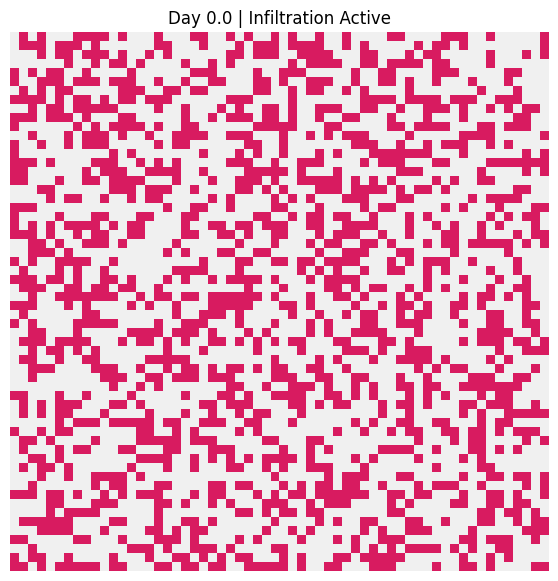

In [12]:

# --- Parameters (Matching yours) ---
p = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.3
}

GRID_SIZE = 60
DAYS = 14
DT = 0.1 
STEPS = int(DAYS / DT)

# Initialize
grids = np.zeros((5, GRID_SIZE, GRID_SIZE))
grids[0] = np.random.choice([0, 1], size=(GRID_SIZE, GRID_SIZE), p=[1-p['C_init'], p['C_init']])

fig, ax = plt.subplots(figsize=(7, 7))
cmap = colors.ListedColormap(['#f0f0f0', '#D81B60', '#FFC107', '#1E88E5']) 
norm = colors.BoundaryNorm([0, 1, 2, 3, 4], cmap.N)
img = ax.imshow(np.zeros((GRID_SIZE, GRID_SIZE)), cmap=cmap, norm=norm, animated=True)
ax.axis('off')

def get_chemotaxis_move(r, c, signal_grid):
    """Finds the best neighboring cell to move to based on signal gradient"""
    best_move = (r, c)
    max_signal = signal_grid[r, c]
    
    # Check 8-neighborhood (Moore neighborhood)
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
            if signal_grid[nr, nc] > max_signal:
                max_signal = signal_grid[nr, nc]
                best_move = (nr, nc)
    return best_move

def update(frame):
    global grids
    # Create Signal Gradient: Cancer cells emit signal, then blur to simulate diffusion
    signal = gaussian_filter(grids[0].astype(float), sigma=2.0)

    # 1. Immune Movement (Chemotaxis)
    # CD8 (index 4) and NK (index 2) move toward higher signal
    for cell_layer in [2, 4]:
        rows, cols = np.where(grids[cell_layer] == 1)
        for r, c in zip(rows, cols):
            new_r, new_c = get_chemotaxis_move(r, c, signal)
            # Only move if the spot is empty of its own kind
            if grids[cell_layer][new_r, new_c] == 0:
                grids[cell_layer][r, c] = 0
                grids[cell_layer][new_r, new_c] = 1

    # 2. Dynamics (Birth/Death/Kill)
    C = np.mean(grids[0])
    N = np.mean(grids[2])
    T8 = np.mean(grids[4])
    D = np.mean(grids[1])
    Tr = np.mean(grids[3])

    # Cancer growth/kill logic
    kill_mask = (np.random.rand(GRID_SIZE, GRID_SIZE) < (p['eta_8']*T8 + p['eta_N']*N + p['d_C'])*DT)
    grids[0][(grids[0] == 1) & kill_mask] = 0
    
    growth_mask = (np.random.rand(GRID_SIZE, GRID_SIZE) < p['lambda_C']*(1-C/p['C_M'])*DT)
    grids[0][(grids[0] == 0) & growth_mask] = 1

    # Simple recruitment for visualization
    if np.random.rand() < p['lambda_T8_comb']*10: # Scaled for visual pop-in
        grids[4][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1

    # Display priorities
    display = np.zeros((GRID_SIZE, GRID_SIZE))
    display[grids[0] == 1] = 1 # Cancer
    display[grids[2] == 1] = 2 # NK
    display[grids[4] == 1] = 3 # CD8
    
    img.set_array(display)
    ax.set_title(f"Day {round(frame * DT, 1)} | Infiltration Active")
    return [img]

ani = FuncAnimation(fig, update, frames=STEPS, interval=100, blit=True)
plt.show()

## adding a counter and saving the animation 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib import colors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

# --- Parameters ---
p = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.2
}

GRID_SIZE = 60
DAYS = 14
DT = 0.1 
STEPS = int(DAYS / DT)

# Initialize Grids
grids = np.zeros((5, GRID_SIZE, GRID_SIZE))
grids[0] = np.random.choice([0, 1], size=(GRID_SIZE, GRID_SIZE), p=[1-p['C_init'], p['C_init']])

# Setup Plot
fig, ax = plt.subplots(figsize=(8, 8))
# 0: Empty, 1: Cancer, 2: NK, 3: CD8
cmap = colors.ListedColormap(['#f0f0f0', '#D81B60', '#FFC107', '#1E88E5']) 
norm = colors.BoundaryNorm([0, 1, 2, 3, 4], cmap.N)
img = ax.imshow(np.zeros((GRID_SIZE, GRID_SIZE)), cmap=cmap, norm=norm)

# Create Legend (The Key)
legend_elements = [
    Patch(facecolor='#D81B60', label='Cancer Cell'),
    Patch(facecolor='#FFC107', label='NK Cell'),
    Patch(facecolor='#1E88E5', label='CD8+ T Cell'),
    Patch(facecolor='#f0f0f0', edgecolor='grey', label='Empty Space')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))
ax.axis('off')

def get_chemotaxis_move(r, c, signal_grid):
    best_move = (r, c)
    max_signal = signal_grid[r, c]
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
            if signal_grid[nr, nc] > max_signal:
                max_signal = signal_grid[nr, nc]
                best_move = (nr, nc)
    return best_move

def update(frame):
    global grids
    # Signal for Chemotaxis
    signal = gaussian_filter(grids[0].astype(float), sigma=2.0)

    # Move Immune Cells (NK and CD8)
    for layer in [2, 4]:
        rows, cols = np.where(grids[layer] == 1)
        for r, c in zip(rows, cols):
            new_r, new_c = get_chemotaxis_move(r, c, signal)
            if grids[layer][new_r, new_c] == 0:
                grids[layer][r, c] = 0
                grids[layer][new_r, new_c] = 1

    # Dynamics
    C_prop = np.mean(grids[0])
    N_prop = np.mean(grids[2])
    T8_prop = np.mean(grids[4])

    # Cancer Growth/Death
    grids[0][(grids[0] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < (p['eta_8']*T8_prop + p['eta_N']*N_prop + p['d_C'])*DT)] = 0
    grids[0][(grids[0] == 0) & (np.random.rand(GRID_SIZE, GRID_SIZE) < p['lambda_C']*(1-C_prop/p['C_M'])*DT)] = 1
    
    # VISUAL BOOST: Force recruitment if counts are low to ensure they appear in the movie
    if np.sum(grids[4]) < 50: # Ensure at least 50 CD8s are patrolling
        grids[4][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1
    if np.sum(grids[2]) < 30: # Ensure some NKs are present
        grids[2][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1

    # Final Display layer
    display = np.zeros((GRID_SIZE, GRID_SIZE))
    display[grids[0] == 1] = 1 
    display[grids[2] == 1] = 2 
    display[grids[4] == 1] = 3 
    
    img.set_array(display)
    ax.set_title(f"Day {round(frame * DT, 1)} | Cancer: {int(np.sum(grids[0]))} | CD8: {int(np.sum(grids[4]))}")
    return [img]

# Save as MP4
writer = FFMpegWriter(fps=15)
ani = FuncAnimation(fig, update, frames=STEPS, blit=True)
ani.save("cancer_simulation_with_key.mp4", writer=writer)
plt.close()
print("Saved: cancer_simulation_with_key.mp4")

Saved: cancer_simulation_with_key.mp4


## going to make the cancer cells just cluster together some more 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib import colors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

# --- Parameters ---
p = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8
}

GRID_SIZE = 60
DAYS = 14
DT = 0.1 
STEPS = int(DAYS / DT)

# Initialize Grids
grids = np.zeros((5, GRID_SIZE, GRID_SIZE))
grids[0] = np.random.choice([0, 1], size=(GRID_SIZE, GRID_SIZE), p=[1-p['C_init'], p['C_init']])

# Setup Plot
fig, ax = plt.subplots(figsize=(8, 8))
# 0: Empty, 1: Cancer, 2: NK, 3: CD8
cmap = colors.ListedColormap(['#f0f0f0', '#D81B60', '#FFC107', '#1E88E5']) 
norm = colors.BoundaryNorm([0, 1, 2, 3, 4], cmap.N)
img = ax.imshow(np.zeros((GRID_SIZE, GRID_SIZE)), cmap=cmap, norm=norm)

# Create Legend (The Key)
legend_elements = [
    Patch(facecolor='#D81B60', label='Cancer Cell'),
    Patch(facecolor='#FFC107', label='NK Cell'),
    Patch(facecolor='#1E88E5', label='CD8+ T Cell'),
    Patch(facecolor='#f0f0f0', edgecolor='grey', label='Empty Space')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))
ax.axis('off')

def get_chemotaxis_move(r, c, signal_grid):
    best_move = (r, c)
    max_signal = signal_grid[r, c]
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
            if signal_grid[nr, nc] > max_signal:
                max_signal = signal_grid[nr, nc]
                best_move = (nr, nc)
    return best_move

def update(frame):
    global grids
    # 1. Signal for Chemotaxis
    signal = gaussian_filter(grids[0].astype(float), sigma=2.0)

    # 2. Move Immune Cells (NK and CD8)
    for layer in [2, 4]:
        rows, cols = np.where(grids[layer] == 1)
        for r, c in zip(rows, cols):
            new_r, new_c = get_chemotaxis_move(r, c, signal)
            if grids[layer][new_r, new_c] == 0:
                grids[layer][r, c] = 0
                grids[layer][new_r, new_c] = 1

    # 3. Calculate Global Proportions
    C_prop = np.mean(grids[0])
    N_prop = np.mean(grids[2])
    T8_prop = np.mean(grids[4])

    # 4. CANCER DEATH (Keep this as is)
    #death_prob = (p['eta_8']*T8_prop + p['eta_N']*N_prop + p['d_C']) * DT
    # Try reducing the multiplier for the ABM specifically
    death_prob = (p['eta_8']*0.1*T8_prop + p['eta_N']*0.1*N_prop + p['d_C']) * DT
    grids[0][(grids[0] == 1) & (np.random.rand(GRID_SIZE, GRID_SIZE) < death_prob)] = 0



    # 5. CANCER GROWTH (NEW CLUSTERING LOGIC)
    # Find all current cancer cells
    c_rows, c_cols = np.where(grids[0] == 1)
    # Shuffle them so the growth isn't biased by array order
    indices = np.arange(len(c_rows))
    np.random.shuffle(indices)
    
    growth_rate = p['lambda_C'] * (1 - C_prop / p['C_M']) * DT
    
    for idx in indices:
        if np.random.rand() < growth_rate:
            r, c = c_rows[idx], c_cols[idx]
            # Look at a random neighbor to place the "daughter" cell
            dr, dc = np.random.choice([-1, 0, 1]), np.random.choice([-1, 0, 1])
            nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
            
            # Only grow if the neighbor spot is empty
            if grids[0][nr, nc] == 0:
                grids[0][nr, nc] = 1

    # 6. VISUAL BOOST (Keep this)
    if np.sum(grids[4]) < 50: 
        grids[4][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1
    if np.sum(grids[2]) < 30: 
        grids[2][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1

    # 7. Final Display layer
    display = np.zeros((GRID_SIZE, GRID_SIZE))
    display[grids[0] == 1] = 1 
    display[grids[2] == 1] = 2 
    display[grids[4] == 1] = 3 
    
    img.set_array(display)
    ax.set_title(f"Day {round(frame * DT, 1)} | Cancer: {int(np.sum(grids[0]))} | CD8: {int(np.sum(grids[4]))}")
    return [img]

# Save as MP4
writer = FFMpegWriter(fps=15)
ani = FuncAnimation(fig, update, frames=STEPS, blit=True)
ani.save("cancer_cluster.mp4", writer=writer)
plt.close()
print("Saved: cancer_cluster.mp4")

Saved: cancer_cluster.mp4


## Make cancer a solid and introduce neighbouring effect 

Starting Solid Tumor Simulation...
Success: Saved 'solid_tumor_battle.mp4'
Day 3 -> CD8: 34.0, NK: 34.0, Ratio: 1.00
Day 7 -> CD8: 60.0, NK: 40.0, Ratio: 1.50


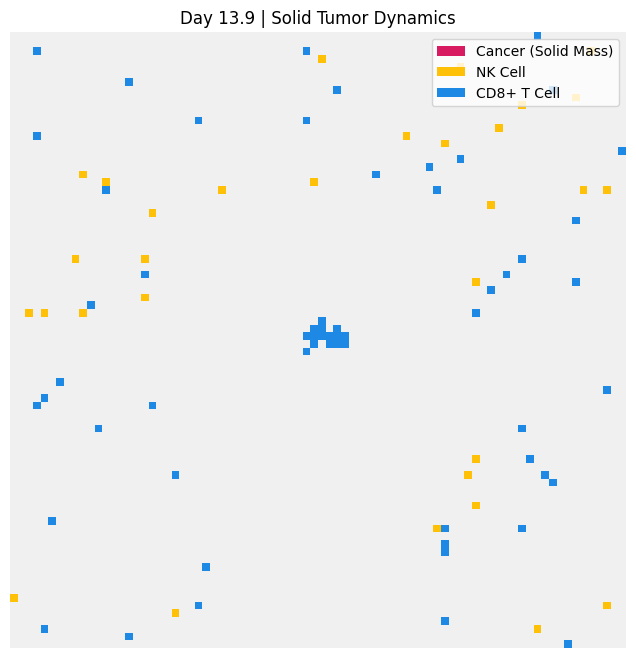

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib import colors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

# --- Parameters (Reduced eta_8 for balance) ---
p = {
    'lambda_C': 0.8, 'C_M': 0.8, 'eta_8': 150.0, 'eta_N': 100.0, 'd_C': 0.05, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004
}

GRID_SIZE = 80 # Slightly larger for better visual
DAYS = 14
DT = 0.1 
STEPS = int(DAYS / DT)

# --- Initialize Grids ---
grids = np.zeros((5, GRID_SIZE, GRID_SIZE))

# Create ONE solid central tumor seed (5x5 block)
mid = GRID_SIZE // 2
grids[0][mid-3:mid+4, mid-3:mid+4] = 1

# Setup Plot
fig, ax = plt.subplots(figsize=(8, 8))
cmap = colors.ListedColormap(['#f0f0f0', '#D81B60', '#FFC107', '#1E88E5']) 
norm = colors.BoundaryNorm([0, 1, 2, 3, 4], cmap.N)
img = ax.imshow(grids[0], cmap=cmap, norm=norm)

legend_elements = [
    Patch(facecolor='#D81B60', label='Cancer (Solid Mass)'),
    Patch(facecolor='#FFC107', label='NK Cell'),
    Patch(facecolor='#1E88E5', label='CD8+ T Cell')
]
ax.legend(handles=legend_elements, loc='upper right')
ax.axis('off')

# Stats tracker
extracted_stats = {}

def get_chemotaxis_move(r, c, signal_grid):
    best_move = (r, c)
    max_s = signal_grid[r, c]
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
        nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
        if signal_grid[nr, nc] > max_s:
            max_s = signal_grid[nr, nc]
            best_move = (nr, nc)
    return best_move

def update(frame):
    global grids
    # 1. Chemotaxis Signal (Tumor Scent)
    signal = gaussian_filter(grids[0].astype(float), sigma=3.0)

    # 2. Immune Movement
    for layer in [2, 4]:
        rows, cols = np.where(grids[layer] == 1)
        for r, c in zip(rows, cols):
            new_r, new_c = get_chemotaxis_move(r, c, signal)
            if grids[layer][new_r, new_c] == 0 and grids[0][new_r, new_c] == 0:
                grids[layer][r, c] = 0
                grids[layer][new_r, new_c] = 1

    # 3. Spatial Growth (Peripheral Division Only)
    C_prop = np.mean(grids[0])
    c_rows, c_cols = np.where(grids[0] == 1)
    # Shuffle to prevent directional bias
    shuffled_idx = np.random.permutation(len(c_rows))
    
    for idx in shuffled_idx:
        if np.random.rand() < p['lambda_C'] * (1 - C_prop/p['C_M']) * DT:
            r, c = c_rows[idx], c_cols[idx]
            # Try to find an empty neighbor to divide into
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
                if grids[0][nr, nc] == 0:
                    grids[0][nr, nc] = 1
                    break

    # 4. Spatial Killing (Only Surface Cells can be killed)
    T8_prop = np.mean(grids[4])
    N_prop = np.mean(grids[2])
    
    for r, c in zip(c_rows, c_cols):
        # Count neighbors - if 8 neighbors, it's inside the core
        # We use a simple check: is it touching an empty space or an immune cell?
        is_exposed = False
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
            if grids[0][nr, nc] == 0: # Touching "air" or immune path
                is_exposed = True
                break
        
        if is_exposed:
            # Only exposed cells face the full wrath of the immune system
            kill_p = (p['eta_8']*T8_prop + p['eta_N']*N_prop + p['d_C']) * DT
            if np.random.rand() < kill_p:
                grids[0][r, c] = 0

    # 5. Recruitment (Keeping numbers up for the visual battle)
    if np.sum(grids[4]) < 60:
        grids[4][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1
    if np.sum(grids[2]) < 40:
        grids[2][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1

    # Data Extraction
    if frame == int(3/DT): extracted_stats['Day 3'] = (np.sum(grids[4]), np.sum(grids[2]))
    if frame == int(7/DT): extracted_stats['Day 7'] = (np.sum(grids[4]), np.sum(grids[2]))

    # Display
    display = np.zeros((GRID_SIZE, GRID_SIZE))
    display[grids[0] == 1] = 1 
    display[grids[2] == 1] = 2 
    display[grids[4] == 1] = 3 
    
    img.set_array(display)
    ax.set_title(f"Day {round(frame * DT, 1)} | Solid Tumor Dynamics")
    return [img]

# --- Save Block ---
print("Starting Solid Tumor Simulation...")
ani = FuncAnimation(fig, update, frames=STEPS, blit=True)

# Fallback Save Logic
try:
    writer = FFMpegWriter(fps=15)
    ani.save("solid_tumor_battle.mp4", writer=writer)
    print("Success: Saved 'solid_tumor_battle.mp4'")
except Exception as e:
    print("FFMpeg failed. Saving as HTML...")
    ani.save("solid_tumor_battle.html", writer='html')

# Final Proportions Output
for day, (t8, nk) in extracted_stats.items():
    ratio = t8/nk if nk > 0 else 0
    print(f"{day} -> CD8: {t8}, NK: {nk}, Ratio: {ratio:.2f}")

In [ ]:
## trying again to increase the size of the tumour

Simulating... check for 'solid_tumor_shielded.mp4'


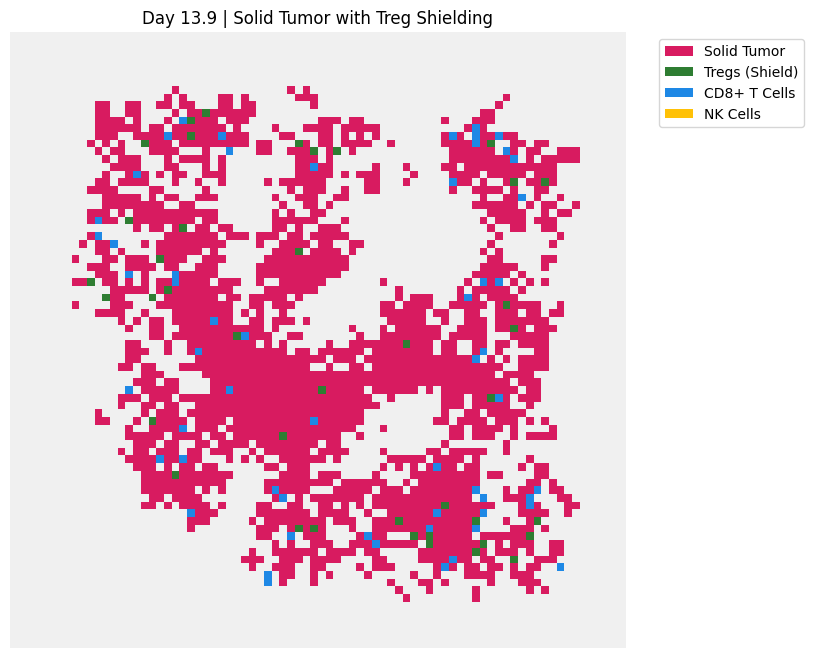

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib import colors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

# --- Parameters (Matching your mutagen_best_params_new) ---
p = {
    'lambda_C': 0.8, 'C_M': 0.8, 'eta_8': 120.0, 'eta_N': 100.0, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.6 # This now controls starting mass size
}

GRID_SIZE = 80
DAYS = 14
DT = 0.1 
STEPS = int(DAYS / DT)

# --- Initialize Grids ---
# 0:C, 1:D, 2:N, 3:Tr, 4:T8
grids = np.zeros((5, GRID_SIZE, GRID_SIZE))

# Use C_init to define a solid square starting block
mid = GRID_SIZE // 2
# We calculate the 'radius' so the area matches the C_init proportion roughly
radius = int(np.sqrt((GRID_SIZE**2 * p['C_init'])) / 2)
grids[0][mid-radius:mid+radius, mid-radius:mid+radius] = 1

# Setup Plot
fig, ax = plt.subplots(figsize=(8, 8))
# Colors: Empty (Grey), Cancer (Red), NK (Yellow), CD8 (Blue), Tregs (Green)
cmap = colors.ListedColormap(['#f0f0f0', '#D81B60', '#FFC107', '#1E88E5', '#2E7D32']) 
norm = colors.BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)
img = ax.imshow(grids[0], cmap=cmap, norm=norm)

legend_elements = [
    Patch(facecolor='#D81B60', label='Solid Tumor'),
    Patch(facecolor='#2E7D32', label='Tregs (Shield)'),
    Patch(facecolor='#1E88E5', label='CD8+ T Cells'),
    Patch(facecolor='#FFC107', label='NK Cells')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
ax.axis('off')

def get_chemotaxis_move(r, c, signal_grid, inverse=False):
    best_move = (r, c)
    max_s = signal_grid[r, c]
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
        nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
        # Regular chemotaxis moves TOWARD signal; inverse (for Tregs) moves AWAY
        if not inverse:
            if signal_grid[nr, nc] > max_s:
                max_s = signal_grid[nr, nc]
                best_move = (nr, nc)
        else: # Inverse logic for "buffering" the tumor
             if signal_grid[nr, nc] < max_s:
                max_s = signal_grid[nr, nc]
                best_move = (nr, nc)
    return best_move

def update(frame):
    global grids
    # 1. Signals
    tumor_signal = gaussian_filter(grids[0].astype(float), sigma=3.0)
    treg_signal = gaussian_filter(grids[3].astype(float), sigma=2.0)

    # 2. Movement
    # CD8s move toward Tumor but are slowed/repelled by Treg signal
    rows8, cols8 = np.where(grids[4] == 1)
    for r, c in zip(rows8, cols8):
        new_r, new_c = get_chemotaxis_move(r, c, tumor_signal - (treg_signal * 2.0))
        if grids[4][new_r, new_c] == 0 and grids[0][new_r, new_c] == 0:
            grids[4][r, c] = 0
            grids[4][new_r, new_c] = 1

    # Tregs (Layer 3) cluster at the tumor boundary
    rowsTr, colsTr = np.where(grids[3] == 1)
    for r, c in zip(rowsTr, colsTr):
        new_r, new_c = get_chemotaxis_move(r, c, tumor_signal)
        # Stay at the edge (don't enter the tumor)
        if grids[0][new_r, new_c] == 0:
            grids[3][r, c] = 0
            grids[3][new_r, new_c] = 1

    # 3. Growth (Peripheral only)
    c_rows, c_cols = np.where(grids[0] == 1)
    C_prop = len(c_rows) / GRID_SIZE**2
    for r, c in zip(c_rows, c_cols):
        if np.random.rand() < p['lambda_C'] * (1 - C_prop/p['C_M']) * DT:
            dr, dc = np.random.choice([-1,0,1]), np.random.choice([-1,0,1])
            nr, nc = (r + dr) % GRID_SIZE, (c + dc) % GRID_SIZE
            if grids[0][nr, nc] == 0: grids[0][nr, nc] = 1

    # 4. Killing (Shielded by neighbors and Tregs)
    T8_prop = np.mean(grids[4])
    Tr_prop = np.mean(grids[3])
    
    for r, c in zip(c_rows, c_cols):
        # Is the cell exposed to 'air'?
        is_exposed = np.any(grids[0][(r-1):(r+2), (c-1):(c+2)] == 0)
        if is_exposed:
            # Shielding factor from nearby Tregs
            local_treg_suppression = 1.0 / (1.0 + treg_signal[r,c]/p['K_Tr'])
            kill_p = (p['eta_8']*T8_prop*local_treg_suppression + p['d_C']) * DT
            if np.random.rand() < kill_p:
                grids[0][r, c] = 0

    # 5. Visual Recruitment
    if np.sum(grids[4]) < 60: grids[4][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1
    if np.sum(grids[3]) < 40: grids[3][np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)] = 1

    # Final Display
    display = np.zeros((GRID_SIZE, GRID_SIZE))
    display[grids[0] == 1] = 1 # Cancer
    display[grids[2] == 1] = 2 # NK
    display[grids[4] == 1] = 3 # CD8
    display[grids[3] == 1] = 4 # Tregs
    
    img.set_array(display)
    ax.set_title(f"Day {round(frame * DT, 1)} | Solid Tumor with Treg Shielding")
    return [img]

# --- Animation Save ---
print("Simulating... check for 'solid_tumor_shielded.mp4'")
ani = FuncAnimation(fig, update, frames=STEPS, blit=True)
try:
    ani.save("solid_tumor_shielded.mp4", writer=FFMpegWriter(fps=15))
except:
    ani.save("solid_tumor_shielded.html", writer='html')